# Assignment 2 - Experiment Tracking
Jugaad Singh Sohal (MDS202421)
## Data Preparation with DVC

Prepare the SMS spam data and use DVC (Data Version Control) to track different versions of our data splits.

### Installing required packages

In [1]:
%pip install pandas matplotlib numpy scikit-learn dvc dvc-gdrive


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import os

### Download the dataset

UCI SMS Spam collection dataset

In [3]:
!mkdir -p data
!wget -q https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip -O data/smsspamcollection.zip
!unzip -o data/smsspamcollection.zip -d data/
!ls data/

Archive:  data/smsspamcollection.zip
  inflating: data/SMSSpamCollection  
  inflating: data/readme             


raw_data.csv	  SMSSpamCollection	 test.csv.dvc	validation.csv
raw_data.csv.dvc  smsspamcollection.zip  train.csv	validation.csv.dvc
readme		  test.csv		 train.csv.dvc


### Load and save raw data

In [4]:
df = pd.read_csv('data/SMSSpamCollection', sep='\t', header=None, names=['label', 'message'], encoding='latin-1')
print(f"Total messages: {len(df)}")
print(f"\nClass distribution:")
print(df['label'].value_counts())
print(f"\nSpam percentage: {(df['label'] == 'spam').mean() * 100:.2f}%")

df.to_csv('data/raw_data.csv', index=False)
print(f"\nSaved raw_data.csv ({len(df)} rows)")
df.head()

Total messages: 5572

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Spam percentage: 13.41%

Saved raw_data.csv (5572 rows)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### Initialize DVC

DVC (Data Version Control) tracks data files alongside git. `dvc init --subdir` initializes DVC inside a subdirectory of the git repository.

In [5]:
!dvc init --subdir

Initialized DVC repository.

You can now commit the changes to git.

+---------------------------------------------------------------------+
|                                                                     |
|        DVC has enabled anonymous aggregate usage analytics.         |
|     Read the analytics documentation (and how to opt-out) here:     |
|             <https://dvc.org/doc/user-guide/analytics>              |
|                                                                     |
+---------------------------------------------------------------------+

What's next?
------------
- Check out the documentation: <https://dvc.org/doc>
- Get help and share ideas: <https://dvc.org/chat>
- Star us on GitHub: <https://github.com/treeverse/dvc>


### Track raw data with DVC

`dvc add` replaces the actual data file with a `.dvc` pointer file in git, and caches the data in `.dvc/cache/`.

In [6]:
!dvc add data/raw_data.csv

⠋ Checking graph
Adding...                                                                       
!


                                                                                
!
  0% Checking cache in '/home/jugaad/github/appliedmachinelearning/Assignment-02
                                                                                
!
  0%|          |Adding data/raw_data.csv to cache     0/1 [00:00<?,     ?file/s]
                                                                                
!
  0%|          |Checking out /home/jugaad/github/appli0/1 [00:00<?,    ?files/s]


100% Adding...|████████████████████████████████████████|1/1 [00:00,  8.75file/s]

To track the changes with git, run:

	git add data/raw_data.csv.dvc

To enable auto staging, run:

	dvc config core.autostage true


### Version 1: Train/Validation/Test Split (random_state=42)

Stratified 70/15/15 split to maintain the same spam/ham ratio in each set.

In [7]:
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

train_df[['label', 'message']].to_csv('data/train.csv', index=False)
val_df[['label', 'message']].to_csv('data/validation.csv', index=False)
test_df[['label', 'message']].to_csv('data/test.csv', index=False)

print(f"Train: {len(train_df)} samples")
print(f"Validation: {len(val_df)} samples")
print(f"Test: {len(test_df)} samples")

print(f"\nTrain distribution:")
print(f"  ham:  {(train_df['label'] == 'ham').sum()}")
print(f"  spam: {(train_df['label'] == 'spam').sum()}")
print(f"\nValidation distribution:")
print(f"  ham:  {(val_df['label'] == 'ham').sum()}")
print(f"  spam: {(val_df['label'] == 'spam').sum()}")
print(f"\nTest distribution:")
print(f"  ham:  {(test_df['label'] == 'ham').sum()}")
print(f"  spam: {(test_df['label'] == 'spam').sum()}")

Train: 3900 samples
Validation: 836 samples
Test: 836 samples

Train distribution:
  ham:  3377
  spam: 523

Validation distribution:
  ham:  724
  spam: 112

Test distribution:
  ham:  724
  spam: 112


In [8]:
!dvc add data/train.csv data/validation.csv data/test.csv

⠋ Checking graph
  0% Adding...|                     | data/train.csv |0/3 [00:00<?,     ?file/s]
!


                                                                                
!
  0% Checking cache in '/home/jugaad/github/appliedmachinelearning/Assignment-02
                                                                                
!
  0%|          |Adding data/train.csv to cache        0/1 [00:00<?,     ?file/s]
                                                                                
!
  0%|          |Checking out /home/jugaad/github/appli0/1 [00:00<?,    ?files/s]


 33% Adding...|████        | data/validation.csv |1/3 [00:00<00:00,  8.05file/s]
!
                                                                                
!
  0% Checking cache in '/home/jugaad/github/appliedmachinelearning/Assignment-02
                                                                                
!
  0%|          |Adding data/validation.csv to cache   0/1 [00:00<?,     ?file/s]
                                                                                
!
  0%|          |Checking out /home/jugaad/github/appli0/1 [00:00<?,    ?files/s]
                                                                                

 33% Adding...|██████            | data/test.csv |1/3 [00:00<00:00,  8.05file/s]
!
                                                                                
!
  0% Checking cache in '/home/jugaad/github/appliedmachinelearning/Assignment-02
                                                                                
!
  0%|          |Adding data/test.csv to cache         0/1 [00:00<?,     ?file/s]
                                                                                
!
  0%|          |Checking out /home/jugaad/github/appli0/1 [00:00<?,    ?files/s]
100% Adding...|████████████████████████████████████████|3/3 [00:00, 14.05file/s]

To track the changes with git, run:

	git add data/validation.csv.dvc data/test.csv.dvc data/train.csv.dvc

To enable auto staging, run:

	dvc config core.autostage true


### Version 2: Updated Split with Different Random Seed (random_state=123)

In [9]:
train_df2, temp_df2 = train_test_split(df, test_size=0.3, random_state=123, stratify=df['label'])
val_df2, test_df2 = train_test_split(temp_df2, test_size=0.5, random_state=123, stratify=temp_df2['label'])

train_df2[['label', 'message']].to_csv('data/train.csv', index=False)
val_df2[['label', 'message']].to_csv('data/validation.csv', index=False)
test_df2[['label', 'message']].to_csv('data/test.csv', index=False)

print(f"Train: {len(train_df2)} samples")
print(f"Validation: {len(val_df2)} samples")
print(f"Test: {len(test_df2)} samples")

print(f"\nTrain distribution:")
print(f"  ham:  {(train_df2['label'] == 'ham').sum()}")
print(f"  spam: {(train_df2['label'] == 'spam').sum()}")
print(f"\nValidation distribution:")
print(f"  ham:  {(val_df2['label'] == 'ham').sum()}")
print(f"  spam: {(val_df2['label'] == 'spam').sum()}")
print(f"\nTest distribution:")
print(f"  ham:  {(test_df2['label'] == 'ham').sum()}")
print(f"  spam: {(test_df2['label'] == 'spam').sum()}")

Train: 3900 samples
Validation: 836 samples
Test: 836 samples

Train distribution:
  ham:  3377
  spam: 523

Validation distribution:
  ham:  724
  spam: 112

Test distribution:
  ham:  724
  spam: 112


In [10]:
!dvc add data/train.csv data/validation.csv data/test.csv

⠋ Checking graph
  0% Adding...|                     | data/train.csv |0/3 [00:00<?,     ?file/s]
!
                                                                                


!
  0% Checking cache in '/home/jugaad/github/appliedmachinelearning/Assignment-02
                                                                                
!
  0%|          |Adding data/train.csv to cache        0/1 [00:00<?,     ?file/s]
                                                                                
!
  0%|          |Checking out /home/jugaad/github/appli0/1 [00:00<?,    ?files/s]
  0% Adding...|                | data/validation.csv |0/3 [00:00<?,     ?file/s]
!
                                                                                


!
  0% Checking cache in '/home/jugaad/github/appliedmachinelearning/Assignment-02
                                                                                
!
  0%|          |Adding data/validation.csv to cache   0/1 [00:00<?,     ?file/s]
                                                                                
!
  0%|          |Checking out /home/jugaad/github/appli0/1 [00:00<?,    ?files/s]
 67% Adding...|████████████      | data/test.csv |2/3 [00:00<00:00, 15.83file/s]
!
                                                                                
!
  0% Checking cache in '/home/jugaad/github/appliedmachinelearning/Assignment-02
                                                                                
!
  0%|          |Adding data/test.csv to cache         0/1 [00:00<?,     ?file/s]
                                                                                
!
  0%|          |Checking out /home/jugaad/github/appli0/1 [00:00<?,    ?files/s]


100% Adding...|████████████████████████████████████████|3/3 [00:00, 17.55file/s]

To track the changes with git, run:

	git add data/train.csv.dvc data/test.csv.dvc data/validation.csv.dvc

To enable auto staging, run:

	dvc config core.autostage true


### Verification

### Checkout Version 1 (random_state=42) using DVC

In [11]:
!git checkout v1 -- data/train.csv.dvc data/validation.csv.dvc data/test.csv.dvc
!dvc checkout

Building workspace index                              |0.00 [00:00,    ?entry/s]

Building workspace index                              |5.00 [00:00, 47.6entry/s]
Comparing indexes                                    |6.00 [00:00, 2.90kentry/s]
Applying changes                                      |3.00 [00:00,   173file/s]


M       data/test.csv
M       data/train.csv
M       data/validation.csv


In [12]:
print("Version 1 (random_state=42)\n")

train_v1 = pd.read_csv('data/train.csv')
val_v1 = pd.read_csv('data/validation.csv')
test_v1 = pd.read_csv('data/test.csv')

print("Train distribution:")
print(f"  ham:  {(train_v1['label'] == 'ham').sum()}")
print(f"  spam: {(train_v1['label'] == 'spam').sum()}")
print(f"\nValidation distribution:")
print(f"  ham:  {(val_v1['label'] == 'ham').sum()}")
print(f"  spam: {(val_v1['label'] == 'spam').sum()}")
print(f"\nTest distribution:")
print(f"  ham:  {(test_v1['label'] == 'ham').sum()}")
print(f"  spam: {(test_v1['label'] == 'spam').sum()}")

Version 1 (random_state=42)



Train distribution:
  ham:  3377
  spam: 523

Validation distribution:
  ham:  724
  spam: 112

Test distribution:
  ham:  724
  spam: 112


### Checkout Version 2 (random_state=123) using DVC

In [13]:
!git checkout v2 -- data/train.csv.dvc data/validation.csv.dvc data/test.csv.dvc
!dvc checkout

!

Building workspace index                              |0.00 [00:00,    ?entry/s]

Building workspace index                              |5.00 [00:00,  107entry/s]
Comparing indexes                                    |6.00 [00:00, 2.92kentry/s]
Applying changes                                      |3.00 [00:00,   218file/s]


M       data/test.csv
M       data/train.csv
M       data/validation.csv


In [14]:
print("Version 2 (random_state=123)\n")

train_v2 = pd.read_csv('data/train.csv')
val_v2 = pd.read_csv('data/validation.csv')
test_v2 = pd.read_csv('data/test.csv')

print("Train distribution:")
print(f"  ham:  {(train_v2['label'] == 'ham').sum()}")
print(f"  spam: {(train_v2['label'] == 'spam').sum()}")
print(f"\nValidation distribution:")
print(f"  ham:  {(val_v2['label'] == 'ham').sum()}")
print(f"  spam: {(val_v2['label'] == 'spam').sum()}")
print(f"\nTest distribution:")
print(f"  ham:  {(test_v2['label'] == 'ham').sum()}")
print(f"  spam: {(test_v2['label'] == 'spam').sum()}")

Version 2 (random_state=123)

Train distribution:
  ham:  3377
  spam: 523

Validation distribution:
  ham:  724
  spam: 112

Test distribution:
  ham:  724
  spam: 112


### Comparing Version 1 vs Version 2

Both versions use stratified splits so the class ratios are preserved, but the actual samples in each set differ.

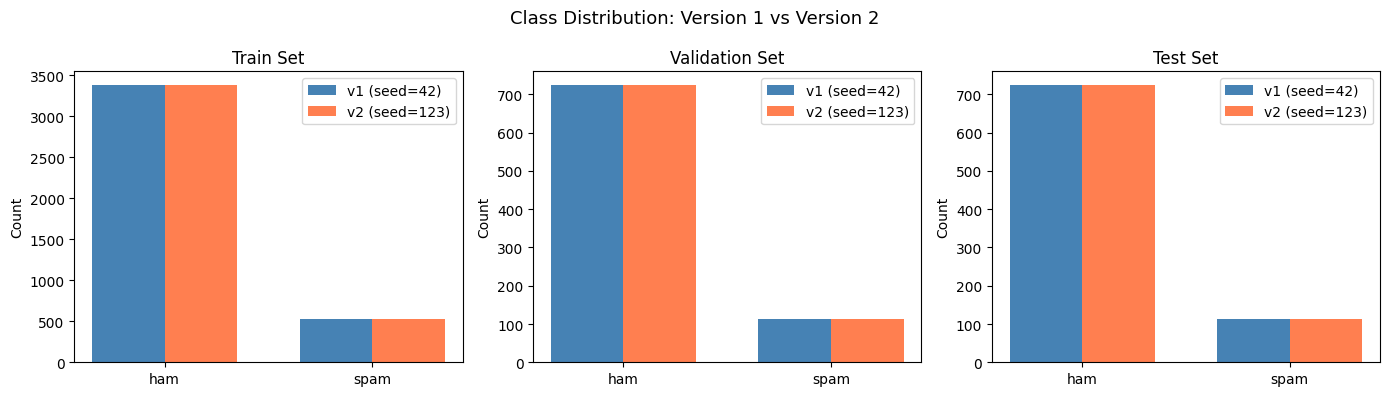

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
splits = ['Train', 'Validation', 'Test']
v1_dfs = [train_v1, val_v1, test_v1]
v2_dfs = [train_v2, val_v2, test_v2]

for ax, name, df_v1, df_v2 in zip(axes, splits, v1_dfs, v2_dfs):
    v1_counts = df_v1['label'].value_counts()
    v2_counts = df_v2['label'].value_counts()

    x = np.arange(2)
    width = 0.35
    ax.bar(x - width/2, [v1_counts.get('ham', 0), v1_counts.get('spam', 0)],
           width, label='v1 (seed=42)', color='steelblue')
    ax.bar(x + width/2, [v2_counts.get('ham', 0), v2_counts.get('spam', 0)],
           width, label='v2 (seed=123)', color='coral')
    ax.set_xticks(x)
    ax.set_xticklabels(['ham', 'spam'])
    ax.set_title(f'{name} Set')
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Class Distribution: Version 1 vs Version 2', fontsize=13)
plt.tight_layout()
plt.show()

#### Verifying the splits contain different samples

In [16]:
v1_train_msgs = set(train_v1['message'])
v2_train_msgs = set(train_v2['message'])
overlap = v1_train_msgs & v2_train_msgs

print(f"V1 train samples: {len(v1_train_msgs)}")
print(f"V2 train samples: {len(v2_train_msgs)}")
print(f"Overlap: {len(overlap)} ({len(overlap)/len(v1_train_msgs)*100:.1f}%)")
print(f"Unique to v1: {len(v1_train_msgs - v2_train_msgs)}")
print(f"Unique to v2: {len(v2_train_msgs - v1_train_msgs)}")

print(f"\nFirst 5 training messages in V1:")
for msg in train_v1['message'].head(5):
    print(f"  - {msg[:80]}")

print(f"\nFirst 5 training messages in V2:")
for msg in train_v2['message'].head(5):
    print(f"  - {msg[:80]}")

V1 train samples: 3691
V2 train samples: 3695
Overlap: 2641 (71.6%)
Unique to v1: 1050
Unique to v2: 1054

First 5 training messages in V1:
  - Goal! Arsenal 4 (Henry, 7 v Liverpool 2 Henry scores with a simple shot from 6 y
  - They said if its gonna snow, it will start around 8 or 9 pm tonite! They are pre
  - Aah bless! How's your arm?
  - Oh k. . I will come tomorrow
  - What's happening with you. Have you gotten a job and have you begun registration

First 5 training messages in V2:
  - 2 and half years i missed your friendship:-)
  - Can you say what happen
  - Went to ganesh dress shop
  - Heart is empty without love.. Mind is empty without wisdom.. Eyes r empty withou
  - Not heard from U4 a while. Call 4 rude chat private line 01223585334 to cum. Wan
